# OptiCore - Option Strategies

Single options are blunt instruments. Combining them shapes the exposure: cap what you
can lose, finance one leg with another, or bet on volatility instead of direction. This
notebook builds the classic structures from real quotes and looks at what each one is
actually long and short:

1. Building legs from chain quotes
2. Long call vs bull call spread
3. Straddle and the expected move
4. Iron condor
5. Position Greeks - the real exposure
6. Covered call (and why a stock is a zero-strike call)

Everything runs **offline** on the sample chain that ships with the package. Payoff
diagrams come from `oc.plot.payoff()`, position Greeks from `oc.greeks()`.

## 0. Setup

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import opticore as oc
import pandas as pd

RATE = 0.045

chain = oc.fetch_chain("SPY", provider="sample")
enriched = oc.enrich(chain, rate=RATE)

spot = chain["underlying_price"].iloc[0]
print(f"spot ${spot:.2f}, {enriched['expiry'].nunique()} expiries")

spot $510.00, 6 expiries


## 1. Building legs from chain quotes

A strategy is just a list of `oc.Leg(kind, strike, qty, premium)` - positive `qty` for
long, negative for short. Instead of inventing premiums we pull mid quotes from the
chain, using the expiry about two months out: long enough that the structures have room
to work, short enough that theta is a real factor.

In [2]:
expiry = sorted(enriched["expiry"].unique())[3]
sub = enriched[enriched["expiry"] == expiry].dropna(subset=["iv"])
calls = sub[sub["kind"] == "call"].set_index("strike")
puts = sub[sub["kind"] == "put"].set_index("strike")

tte = sub["tte"].iloc[0]


def leg(kind, strike, qty=1):
    side = calls if kind == "call" else puts
    return oc.Leg(kind, strike, qty, premium=side.loc[strike, "mid"])


def strike_by_delta(side, target):
    return (side["delta"] - target).abs().idxmin()


atm = (calls.index.to_series() - spot).abs().idxmin()
c25 = strike_by_delta(calls, 0.25)
p25 = strike_by_delta(puts, -0.25)

print(f"{tte * 365:.0f} days to expiry")
print(f"ATM strike {atm}, 25-delta call {c25}, 25-delta put {p25}")

70 days to expiry
ATM strike 508.5, 25-delta call 538.5, 25-delta put 488.5


## 2. Long call vs bull call spread

Same directional view, different cost. The spread sells a 25-delta call against the
long ATM call: the premium collected lowers the cost and the break-even, in exchange
for capping the upside at the short strike.

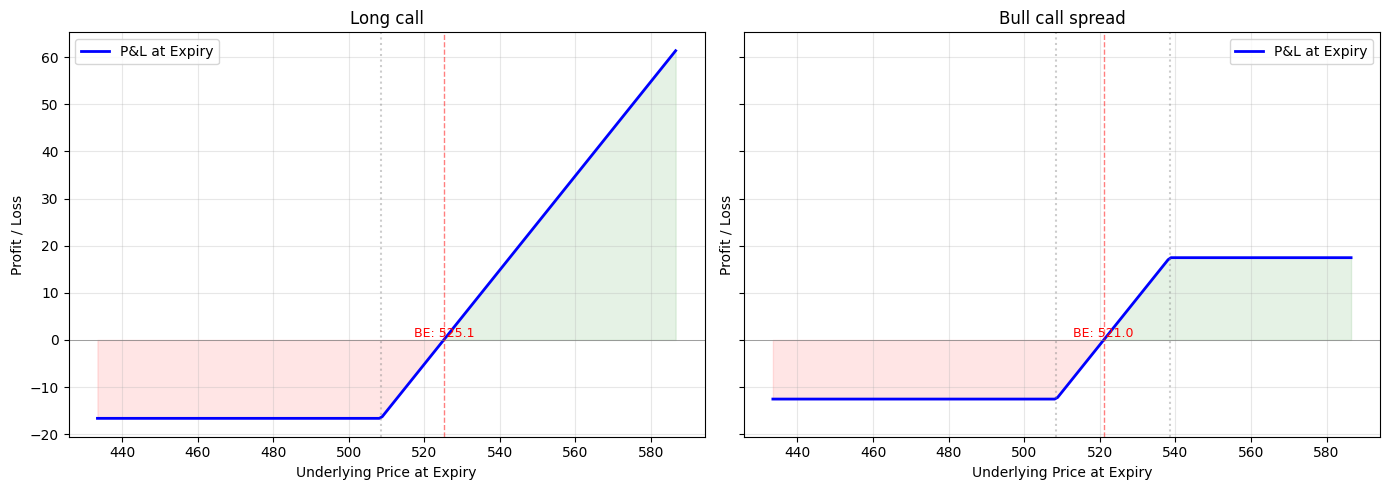

long call: pay 16.64, unlimited upside
spread:    pay 12.55, max profit 17.45 (width 30 - debit)


In [3]:
long_call = [leg("call", atm)]
bull_spread = [leg("call", atm), leg("call", c25, qty=-1)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
oc.plot.payoff(long_call, spot_range=(spot * 0.85, spot * 1.15), ax=axes[0])
oc.plot.payoff(bull_spread, spot_range=(spot * 0.85, spot * 1.15), ax=axes[1])
axes[0].set_title("Long call")
axes[1].set_title("Bull call spread")
plt.show()

debit_call = long_call[0].premium
debit_spread = sum(x.qty * x.premium for x in bull_spread)
width = c25 - atm
print(f"long call: pay {debit_call:.2f}, unlimited upside")
print(f"spread:    pay {debit_spread:.2f}, max profit {width - debit_spread:.2f} "
      f"(width {width:.0f} - debit)")

The spread costs less than the call alone and breaks even closer to spot. The price of
that comfort is visible on the right: past the short strike the line goes flat. Pick
the spread when you expect a move *to* a level, the call when you expect a move
*through* it.

## 3. Straddle and the expected move

Buy the ATM call and put together and direction stops mattering - only the size of the
move does. The natural benchmark is the **expected move** implied by ATM vol:
`spot * iv * sqrt(tte)`, one standard deviation of the terminal distribution.

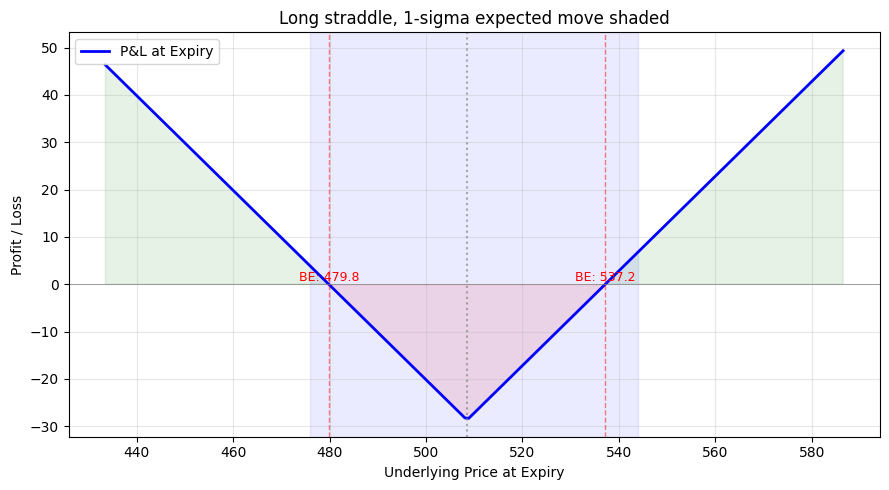

straddle costs 28.67, break-evens at 479.8 / 537.2
expected move +/- 34.05 (ATM IV 15.3%)


In [4]:
straddle = [leg("call", atm), leg("put", atm)]
cost = sum(x.premium for x in straddle)
atm_iv = calls.loc[atm, "iv"]
expected_move = spot * atm_iv * np.sqrt(tte)

fig, ax = plt.subplots(figsize=(9, 5))
oc.plot.payoff(straddle, spot_range=(spot * 0.85, spot * 1.15), ax=ax)
ax.axvspan(spot - expected_move, spot + expected_move, alpha=0.08, color="blue")
ax.set_title("Long straddle, 1-sigma expected move shaded")
plt.show()

print(f"straddle costs {cost:.2f}, break-evens at {atm - cost:.1f} / {atm + cost:.1f}")
print(f"expected move +/- {expected_move:.2f} (ATM IV {atm_iv:.1%})")

The break-evens land just inside the shaded band - the old desk rule that a straddle
costs about 0.8x the expected move. Buying it is a bet that realized volatility beats
implied, not just that "something will happen".

## 4. Iron condor

The other side of that bet. Sell the 25-delta call and put, then buy wings three
strikes further out to cap the damage. The structure collects a credit and keeps it
if the underlying stays inside the short strikes.

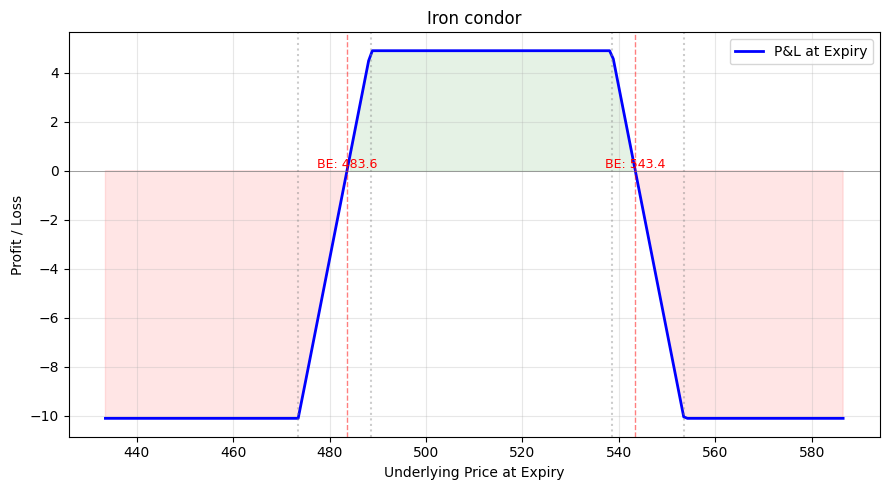

credit 4.90, max loss 10.10 (wing width 15 - credit)
risk/reward: lose up to 2.1x the credit


In [5]:
step = 5.0
condor = [
    leg("put", p25 - 3 * step),
    leg("put", p25, qty=-1),
    leg("call", c25, qty=-1),
    leg("call", c25 + 3 * step),
]

credit = -sum(x.qty * x.premium for x in condor)
max_loss = 3 * step - credit

fig, ax = plt.subplots(figsize=(9, 5))
oc.plot.payoff(condor, spot_range=(spot * 0.85, spot * 1.15), ax=ax)
ax.set_title("Iron condor")
plt.show()

print(f"credit {credit:.2f}, max loss {max_loss:.2f} (wing width {3 * step:.0f} - credit)")
print(f"risk/reward: lose up to {max_loss / credit:.1f}x the credit")

## 5. Position Greeks - the real exposure

Payoff at expiry hides what happens *before* expiry. Summing `oc.greeks()` across legs
(weighted by quantity) shows what the position is long and short right now.

In [6]:
def position_greeks(legs):
    rows = []
    for x in legs:
        side = calls if x.kind == "call" else puts
        g = oc.greeks(spot, x.strike, tte, RATE, side.loc[x.strike, "iv"], kind=x.kind)
        rows.append({"kind": x.kind, "strike": x.strike, "qty": x.qty,
                     **{k: x.qty * v for k, v in g._asdict().items()}})
    df = pd.DataFrame(rows)
    return df, df[["delta", "gamma", "theta", "vega"]].sum()


for name, legs_ in [("straddle", straddle), ("iron condor", condor)]:
    _, net = position_greeks(legs_)
    print(f"{name:12s} delta {net['delta']:+.3f}  gamma {net['gamma']:+.4f}  "
          f"theta {net['theta']:+.3f}  vega {net['vega']:+.3f}")

straddle     delta +0.159  gamma +0.0220  theta -0.206  vega +1.746
iron condor  delta -0.037  gamma -0.0059  theta +0.044  vega -0.427


Mirror images. The straddle is long gamma and vega and pays for it through theta - it
bleeds a little every quiet day. The condor collects that bleed and is short the same
risks. Neither has meaningful delta, which is the point: these are volatility trades,
and the Greeks make that explicit where the payoff diagram does not.

In [7]:
detail, _ = position_greeks(condor)
detail.round(4)

,kind,strike,qty,price,delta,gamma,theta,vega,rho
0,put,473.5,1,3.84,-0.1588,0.0055,-0.0661,0.5407,-0.1626
1,put,488.5,-1,-6.19,0.2459,-0.0077,0.0755,-0.7033,0.2522
2,call,538.5,-1,-4.09,-0.2338,-0.0099,0.0817,-0.6841,-0.2207
3,call,553.5,1,1.54,0.1099,0.0063,-0.0467,0.4196,0.1045


## 6. Covered call (and why a stock is a zero-strike call)

`oc.plot.payoff()` only knows option legs, but it does not need a stock type: a call
with strike 0 *is* the stock (it is always exercised, and its intrinsic value equals
the share price). Set its premium to the purchase price and any stock-plus-options
position fits the same API.

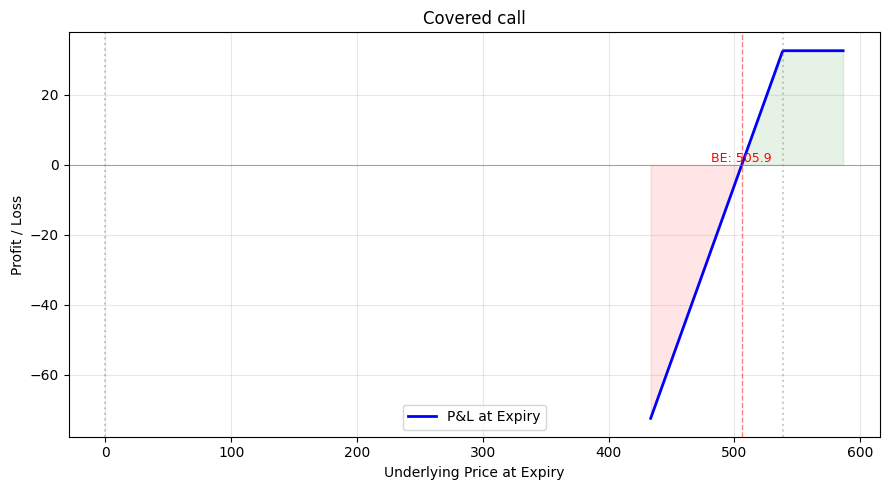

collect 4.09 now; upside capped at 538.5 (+32.59 max)


In [8]:
covered_call = [
    oc.Leg("call", 0.0, qty=1, premium=spot),  # the shares, bought at spot
    leg("call", c25, qty=-1),
]

fig, ax = plt.subplots(figsize=(9, 5))
oc.plot.payoff(covered_call, spot_range=(spot * 0.85, spot * 1.15), ax=ax)
ax.set_title("Covered call")
plt.show()

prem = -covered_call[1].qty * covered_call[1].premium
print(f"collect {prem:.2f} now; upside capped at {c25:.1f} "
      f"(+{c25 - spot + prem:.2f} max)")

Below the strike the line is just stock ownership shifted up by the premium - the call
income cushions small drawdowns but does nothing against a real fall. The flat section
past the strike is the upside given away.

## Where to next

- The IV inputs behind these trades: `04_iv_analysis.ipynb`
- Run on live quotes instead of the sample chain: `03_yfinance_tutorial.ipynb`
- Phase 4 of the [roadmap](../ROADMAP.md) promotes these structures to first-class
  objects (`Spread`, `IronCondor`) with P&L attribution